# Import Statements

In [1]:
import pandas as pd
import urllib.request
import requests
import time
import os
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns

from bs4 import BeautifulSoup
from PIL import Image

# Loading file

In [2]:
multimedia = pd.read_csv("multimedia.txt", sep="\t", on_bad_lines='warn',low_memory=False)

In [3]:
display(multimedia.head(5))

,gbifID,type,format,identifier,references,title,description,source,audience,created,creator,contributor,publisher,license,rightsHolder
0,1459884090,NaN,NaN,NaN,https://www.artportalen.se/Image/622015,NaN,NaN,NaN,NaN,2012-06-06,NaN,NaN,NaN,© all rights reserved,Christer Eriksson
1,3767925412,NaN,NaN,NaN,https://www.artportalen.se/Image/3785511,NaN,NaN,NaN,NaN,2022-02-07,NaN,NaN,NaN,© all rights reserved,Stefan Risberg
2,3767925412,NaN,NaN,NaN,https://www.artportalen.se/Image/3785512,NaN,NaN,NaN,NaN,2022-02-07,NaN,NaN,NaN,© all rights reserved,Stefan Risberg
3,1431465633,NaN,NaN,NaN,https://www.artportalen.se/Image/1567938,NaN,NaN,NaN,NaN,2016-06-02,NaN,NaN,NaN,© all rights reserved,Johan Ennerfelt
4,1431465633,NaN,NaN,NaN,https://www.artportalen.se/Image/1567936,NaN,NaN,NaN,NaN,2016-06-02,NaN,NaN,NaN,© all rights reserved,Johan Ennerfelt


In [8]:
url_list = multimedia['references'].tolist()

len_images = len(url_list)
print(f"Number of images: {len_images}")

Number of images: 330580


# Printing the HTML data

In [28]:
multimedia.loc[multimedia['gbifID'] == 1458513814, 'references']

16106    https://www.artportalen.se/Image/537737
16107    https://www.artportalen.se/Image/537738
Name: references, dtype: object

In [29]:
page = requests.get("https://www.artportalen.se/Image/537737")
soup = BeautifulSoup(page.text, "html.parser")
print(soup.prettify())  # Print the HTML content for debugging

<!DOCTYPE html>
<html dir="ltr" id="c752" lang="sv-SE">
 <head>
  <link href="/favicon.ico" rel="icon" type="image/ico"/>
  <link href="/apple-touch-icon-precomposed.png" rel="apple-touch-icon"/>
  <link href="/apple-touch-icon-120x120-precomposed.png" rel="apple-touch-icon"/>
  <link href="/apple-touch-icon-precomposed.png" rel="apple-touch-icon-precomposed"/>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <script type="text/javascript">
   window.NREUM||(NREUM={});NREUM.info = {"beacon":"bam.nr-data.net","errorBeacon":"bam.nr-data.net","licenseKey":"5e56a8b7c6","applicationID":"3094242","transactionName":"Yl1TZhECXEdYVUBcC1sXcGEzTERdXEFHGglQXFhTTApfVV5TGlQXRUA=","queueTime":0,"applicationTime":41,"agent":"","atts":""}
  </script>
  <script type="text/javascript">
   (window.NREUM||(NREUM={})).init={ajax:{deny_list:["bam.nr-data.net"]}};(window.NREUM||(NREUM={})).loader_config={xpid:"Ug4HV1VbGwAAXVVQAwM=",licenseKey:"5e56a8b7c6",applicationID:"3094242"};;/*! 

# Downloading the Images

In [2]:
source_path = "/home/mrajaraman/dataset/Images"

In [3]:
# url = "https://www.artportalen.se/Image/622015"
headers = {
    "User-Agent": "Mozilla/5.0"  # Some websites require a user-agent
}

for i, url in zip(multimedia['gbifID'], multimedia['references']):

    try:
        page = requests.get(url, headers=headers, timeout=10)
        soup = BeautifulSoup(page.text, "html.parser")
        og_image_tag = soup.find("meta", property="og:image")

        if og_image_tag and og_image_tag.get("content"):
            og_image_url = og_image_tag["content"]
            # print("Original OG Image URL:", og_image_url)

            # Force HTTPS if HTTP
            if og_image_url.startswith("http://"):
                og_image_url = og_image_url.replace("http://", "https://", 1)
                # print("Corrected OG Image URL:", og_image_url)
            
            if "/small/" in og_image_url:
                og_image_url = og_image_url.replace("/small/", "/large/")
            elif "_thumbnail" in og_image_url:
                og_image_url = og_image_url.replace("_thumbnail", "_image")
            else:
                og_image_url = og_image_url
        
            try:
                # print("OG Image URL:", og_image_url)
                img_response = requests.get(og_image_url, headers=headers, timeout=10)
                img_response.raise_for_status()
                filename = os.path.join(source_path, f"img_{i}.jpg")
                if os.path.exists(filename):
                    print(f"File {filename} already exists. Skipping download.")
                    continue
                else:
                    print(f"Downloading image to {filename}...")
                    with open(filename, "wb") as f:
                        f.write(img_response.content)
                    print("Image downloaded successfully.")
            except requests.exceptions.RequestException as e:
                print("Error downloading image:", e)
        else:
            print("og:image not found.")
        time.sleep(1)  # Be polite to servers
    except requests.exceptions.RequestException as e:
        print("Error fetching page:", e)

NameError: name 'multimedia' is not defined

# Basic Statistics

In [4]:
occurrences = pd.read_csv(r"F:\College\Masters\Thesis\occurrence.txt", sep="\t", on_bad_lines='warn', low_memory=False)

In [9]:
display(occurrences['gbifRegion'].head(5))

0    EUROPE
1    EUROPE
2    EUROPE
3    EUROPE
4    EUROPE
Name: gbifRegion, dtype: object

In [18]:
sns.set_theme(rc={'figure.figsize':(25,8.27)})

In [22]:
occurrences['species'].nunique()

142

In [21]:
display(occurrences['species'].value_counts())

species
Orthetrum cancellatum     60040
Anax imperator            42998
Calopteryx splendens      35432
Sympetrum sanguineum      33585
Ischnura elegans          31182
                          ...  
Agriocnemis pygmaea           1
Coenagrion castellani         1
Boyeria cretensis             1
Pseudagrion sublacteum        1
Crocothemis servilia          1
Name: count, Length: 142, dtype: int64

<Axes: xlabel='level0Gid', ylabel='count'>

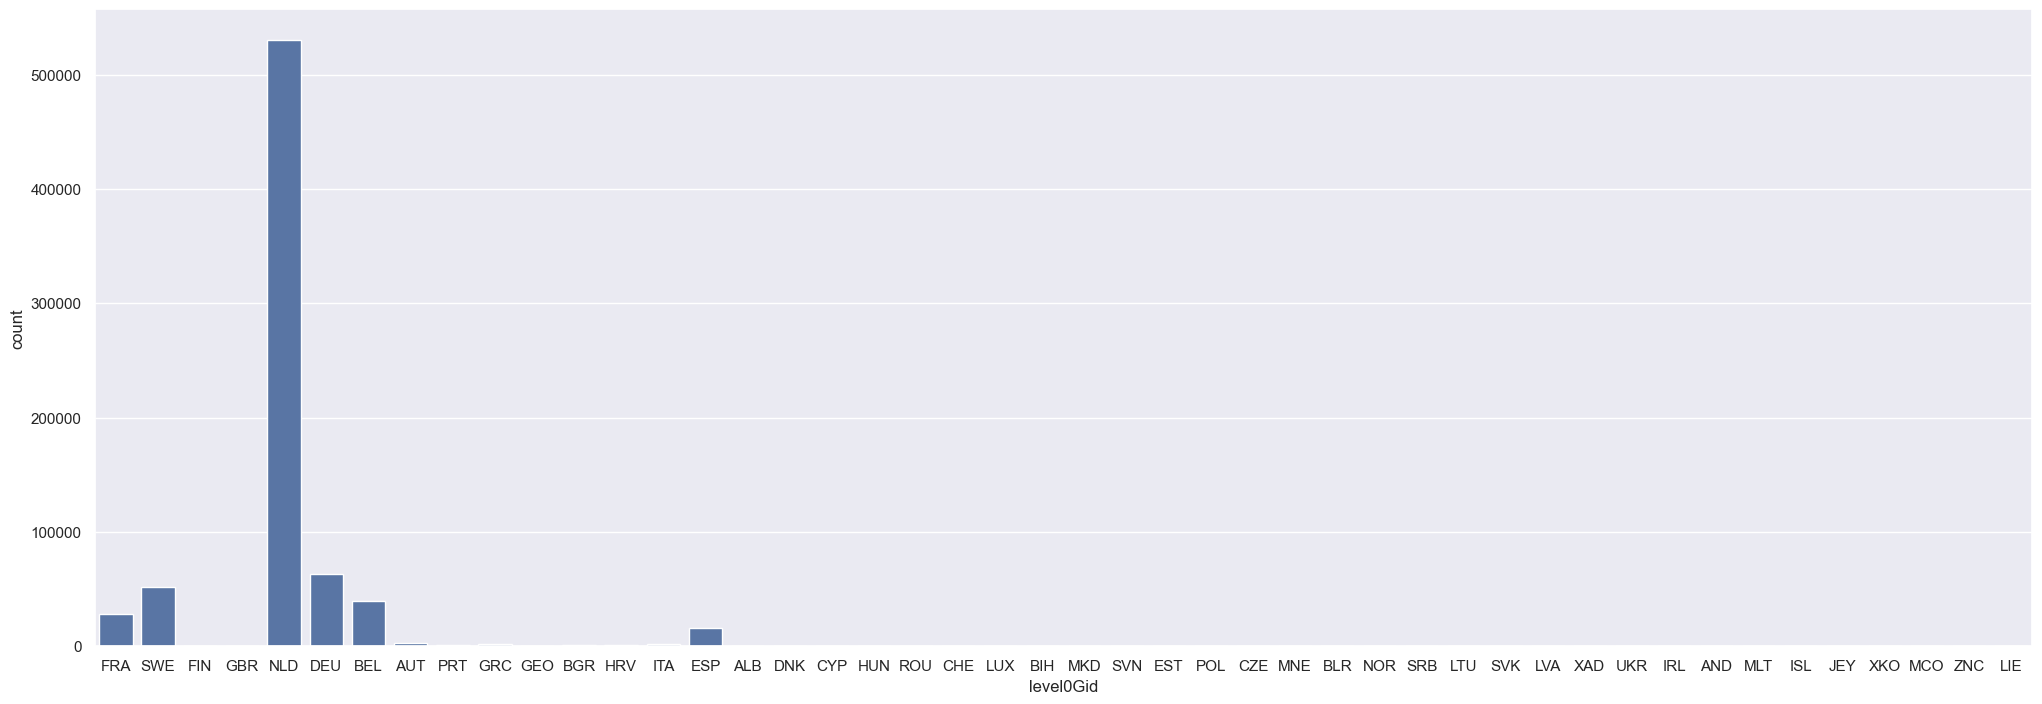

In [19]:
sns.countplot(x='level0Gid', data=occurrences)

In [16]:
print(occurrences.gbifID.nunique())

759423


In [24]:
occurrences_multimedia = pd.merge(
    left=multimedia, 
    right=occurrences,
    how='inner',
    left_on=['gbifID'],
    right_on=['gbifID']
)

In [25]:
print(occurrences_multimedia.level0Gid.unique())

['SWE' nan 'FIN' 'NLD' 'BEL' 'FRA' 'DEU' 'ESP' 'GRC' 'GBR' 'AUT' 'ROU'
 'ITA' 'BGR' 'EST' 'PRT' 'GEO' 'HRV' 'DNK' 'CHE' 'HUN' 'CYP' 'POL' 'SVN'
 'LUX' 'ALB' 'NOR' 'CZE' 'BIH' 'SVK' 'LTU' 'MNE' 'XAD' 'SRB' 'UKR' 'LVA'
 'IRL' 'MLT' 'MKD' 'AND' 'BLR' 'JEY' 'XKO' 'MCO']
